---
title: CSDA data access example
description: This notebook demonstrates simple steps for accessing and plotting CSDA Disasters datasets. 
author: 
  - Brian Freitag
date: February 04, 2026
execute:
   freeze: true
---

# Run This Notebook

<h3><a href="https://hub.disasters.2i2c.cloud/hub/user-redirect/git-pull?repo=https://github.com/Disasters-Learning-Portal/disasters-docs&urlpath=lab/tree/disasters-docs/Jupyterhub/CSDA-demo.ipynb&branch=main">🚀 Launch in Disasters-Hub JupyterHub (requires access)</a></h3>


In [ ]:

import boto3
import folium
import json
import numpy
import os
import rasterio as rio

from rasterio.plot import show
from rasterio.warp import transform_bounds

In [2]:
buckets = {
    "vendors":
    [
        {
            "airbus-optical": "csda-data-vendor-airbus-optical"
        },
        {
            "ghgsat": "csdap-ghgsat-delivery"
        },
        {
            "umbra": "csda-data-vendor-umbra"
        },
        {
            "capellaspace": "csdap-capellaspace-delivery"
        },
        {
            "airbus": "csdap-airbus-delivery"
        },
        {
            "blacksky": "csdap-blacksky-delivery"
        },
        {
            "satellogic": "csda-data-vendor-satellogic"
        },
        {
            "iceye": "csdap-iceye-delivery"
        }
    ]
}

In [3]:

for vendor in buckets.get("vendors"):
    for name, bucket in vendor.items():
        print(f"\33[1m{name}\33[0m data is available in s3://{bucket}/disasters")

airbus-optical data is available in s3://csda-data-vendor-airbus-optical/disasters
ghgsat data is available in s3://csdap-ghgsat-delivery/disasters
umbra data is available in s3://csda-data-vendor-umbra/disasters
capellaspace data is available in s3://csdap-capellaspace-delivery/disasters
airbus data is available in s3://csdap-airbus-delivery/disasters
blacksky data is available in s3://csdap-blacksky-delivery/disasters
satellogic data is available in s3://csda-data-vendor-satellogic/disasters
iceye data is available in s3://csdap-iceye-delivery/disasters


In [4]:
#let's test with Satellogic for the Southeastern ice storm
test_path = "s3://csda-data-vendor-satellogic/disasters/20260128_155747_002_SN33_L1D_SR_MS_341271/"

s3_client = boto3.client('s3')
objects = s3_client.list_objects(Bucket="csda-data-vendor-satellogic", Prefix="disasters/20260128_155747_002_SN33_L1D_SR_MS_341271/" )
for key_metadata in objects.get("Contents"):
    print(key_metadata.get("Key"))

disasters/20260128_155747_002_SN33_L1D_SR_MS_341271/20260128_155747_002_SN33_L1D_SR_MS_341271_manifest.txt
disasters/20260128_155747_002_SN33_L1D_SR_MS_341271/20260128_155747_002_SN33_L1D_SR_MS_341271_manifest.txt.sig
disasters/20260128_155747_002_SN33_L1D_SR_MS_341271/20260128_155747_002_SN33_L1D_SR_MS_CLOUD.vrt
disasters/20260128_155747_002_SN33_L1D_SR_MS_341271/20260128_155747_002_SN33_L1D_SR_MS_TOA.vrt
disasters/20260128_155747_002_SN33_L1D_SR_MS_341271/20260128_155747_002_SN33_L1D_SR_MS_TOA.vrt.ovr
disasters/20260128_155747_002_SN33_L1D_SR_MS_341271/20260128_155747_002_SN33_L1D_SR_MS_VISUAL.vrt
disasters/20260128_155747_002_SN33_L1D_SR_MS_341271/20260128_155747_002_SN33_L1D_SR_MS_VISUAL.vrt.ovr
disasters/20260128_155747_002_SN33_L1D_SR_MS_341271/20260128_155747_002_SN33_L1D_SR_MS_footprint.kml
disasters/20260128_155747_002_SN33_L1D_SR_MS_341271/20260128_155747_002_SN33_L1D_SR_MS_metadata_iso.xml
disasters/20260128_155747_002_SN33_L1D_SR_MS_341271/20260128_155747_002_SN33_L1D_SR_MS

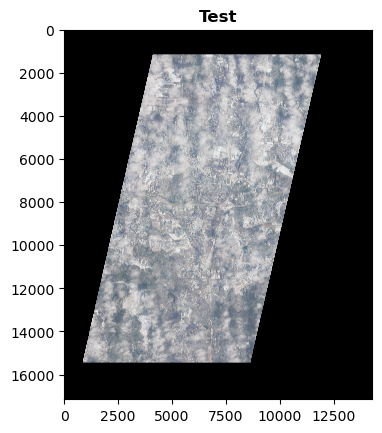

<Axes: title={'center': 'Test'}>

In [5]:
#let's test with the Visual tif
filename = f"{test_path}rasters/20260128_155747_002_SN33_L1D_SR_MS_VISUAL_0.tif"
with rio.open(filename) as src:
    composite = src.read()
    bounds_latlon = transform_bounds(src.crs, 'EPSG:4326', src.bounds.left, src.bounds.bottom, src.bounds.right, src.bounds.top)
center_latlon = src.lnglat()
show(composite, with_bounds=True, title="Test")

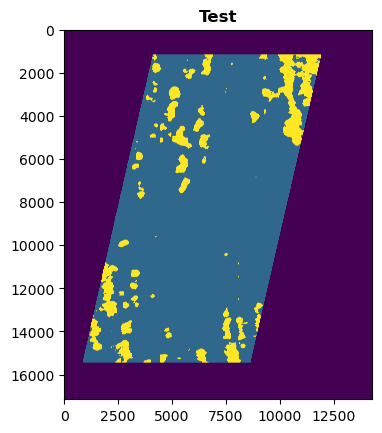

<Axes: title={'center': 'Test'}>

In [6]:
#let's test with the Cloud tif
filename = f"{test_path}rasters/20260128_155747_002_SN33_L1D_SR_MS_CLOUD_0.tif"
with rio.open(filename) as src:
    mask = src.read()

show(mask, with_bounds=True, title="Test")